# CSoT'26 — ML in Astronomy — Week 4: CLIP Zero-Shot Lens Hunter

**Goal:** Use a frozen, pretrained CLIP model to rank Euclid cutouts by how lens-like they look — no training. Evaluate with precision, recall, and ROC, not accuracy.

> Switch runtime to **GPU**: `Runtime → Change runtime type → GPU`

## Step 0 — Install libraries and pick a device

In [1]:
!pip install -q datasets transformers

In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay,
    classification_report, precision_recall_curve
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


## Step 1 — Load the Euclid strong-lens dataset

Each example has an `image`, a `label` (0 = not a lens, 1 = grade-A/B lens), and an `id_str`.

In [3]:
from datasets import load_dataset

print("Loading dataset (first run downloads ~1 GB, cached after that)...")
ds_train = load_dataset(
    'mwalmsley/euclid_strong_lens_expert_judges',
    'classification',
    split='train'
)
ds_test = load_dataset(
    'mwalmsley/euclid_strong_lens_expert_judges',
    'classification',
    split='test'
)

print("Train:", ds_train)
print("Test :", ds_test)

Loading dataset (first run downloads ~1 GB, cached after that)...


README.md:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

classification/train-00000-of-00001.parq(…):   0%|          | 0.00/87.3M [00:00<?, ?B/s]

classification/test-00000-of-00001.parqu(…):   0%|          | 0.00/22.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5876 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1476 [00:00<?, ? examples/s]

Train: Dataset({
    features: ['image', 'label', 'id_str'],
    num_rows: 5876
})
Test : Dataset({
    features: ['image', 'label', 'id_str'],
    num_rows: 1476
})


## Step 2 — Class balance

Lenses are rare. A model that predicts 'not a lens' for everything scores high accuracy but finds zero lenses.

In [4]:
y_train = np.array(ds_train['label'])
y_test  = np.array(ds_test['label'])

print(f"Train size : {len(y_train):,}  |  lenses: {y_train.sum():,}  non-lenses: {(y_train==0).sum():,}")
print(f"Test  size : {len(y_test):,}  |  lenses: {y_test.sum():,}  non-lenses: {(y_test==0).sum():,}")
print(f"Test positive fraction : {y_test.mean():.3f}  ({y_test.mean()*100:.1f}% are lenses)")

naive_acc = 1 - y_test.mean()
print(f"\nNaive 'say no to everything' accuracy : {naive_acc:.3f}")
print("→ This is why accuracy is misleading for rare-event detection.")

Train size : 5,876  |  lenses: 394  non-lenses: 5,482
Test  size : 1,476  |  lenses: 104  non-lenses: 1,372
Test positive fraction : 0.070  (7.0% are lenses)

Naive 'say no to everything' accuracy : 0.930
→ This is why accuracy is misleading for rare-event detection.


## Step 3 — Look at the data

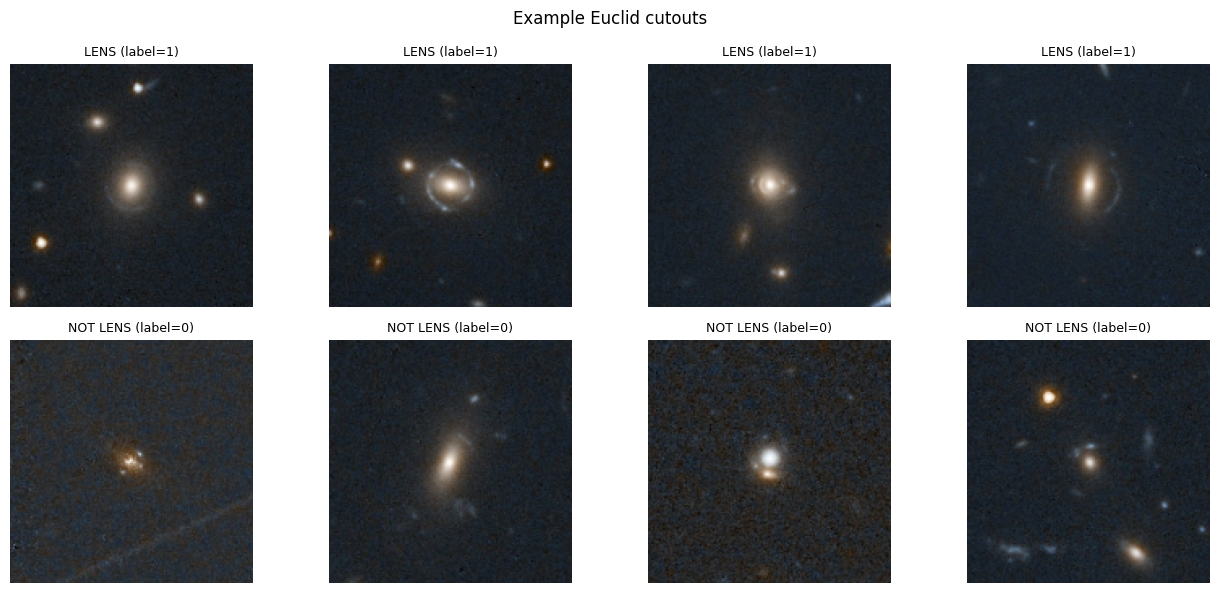

In [5]:
pos_idx = [i for i, y in enumerate(ds_test['label']) if y == 1][:4]
neg_idx = [i for i, y in enumerate(ds_test['label']) if y == 0][:4]

fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for ax, i in zip(axes[0], pos_idx):
    ax.imshow(ds_test[i]['image'])
    ax.set_title('LENS (label=1)', fontsize=9)
    ax.axis('off')
for ax, i in zip(axes[1], neg_idx):
    ax.imshow(ds_test[i]['image'])
    ax.set_title('NOT LENS (label=0)', fontsize=9)
    ax.axis('off')

plt.suptitle('Example Euclid cutouts', fontsize=12)
plt.tight_layout()
plt.show()

## Step 4 — Load CLIP

We use the frozen model — `eval()` mode, no gradients, no weight updates.

In [6]:
from transformers import CLIPModel, CLIPProcessor

MODEL_ID = 'openai/clip-vit-base-patch32'
print(f"Loading {MODEL_ID}...")

clip_model     = CLIPModel.from_pretrained(MODEL_ID).to(device).eval()
clip_processor = CLIPProcessor.from_pretrained(MODEL_ID)

total_params = sum(p.numel() for p in clip_model.parameters())
print(f"CLIP parameters : {total_params:,}  (all frozen — we never call .backward())")

Loading openai/clip-vit-base-patch32...


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP parameters : 151,277,313  (all frozen — we never call .backward())


## Step 5 — Build a prompt bank and embed it

Non-lens prompts name the decoys (spiral arms, rings) so CLIP can distinguish them from genuine lensing arcs.

In [7]:
lens_prompts = [
    "a strong gravitational lens with an Einstein ring",
    "a gravitational lens arc curving around a galaxy",
    "multiple distorted images of a background source due to gravitational lensing",
    "a bright arc or ring caused by gravitational lensing in a galaxy survey",
]

nonlens_prompts = [
    "a normal galaxy without any gravitational lensing",
    "a spiral galaxy with curved arms but no gravitational lens arc",
    "a smooth elliptical galaxy with no lensing features",
    "a ring galaxy formed by a galactic collision not gravitational lensing",
]

all_prompts = lens_prompts + nonlens_prompts
n_lens      = len(lens_prompts)

# Embed all prompts — robust to different transformers versions
text_inputs = clip_processor(
    text=all_prompts, return_tensors='pt', padding=True
).to(device)

with torch.no_grad():
    # Access text model and projection directly to get a plain tensor
    text_out = clip_model.text_model(**text_inputs)
    text_emb = clip_model.text_projection(text_out.pooler_output)

text_emb = F.normalize(text_emb, dim=-1)   # (num_prompts, D)
print(f"Text embeddings : {text_emb.shape}  ({n_lens} lens, {len(nonlens_prompts)} non-lens)")

Text embeddings : torch.Size([8, 512])  (4 lens, 4 non-lens)


## Step 6 — Embed all test images (in batches)

In [8]:
images     = [ex.convert('RGB') for ex in ds_test['image']]
img_embs   = []
BATCH_SIZE = 64

for start in range(0, len(images), BATCH_SIZE):
    chunk  = images[start : start + BATCH_SIZE]
    inputs = clip_processor(images=chunk, return_tensors='pt').to(device)
    with torch.no_grad():
        # Access vision model and projection directly to get a plain tensor
        vision_out = clip_model.vision_model(**inputs)
        emb = clip_model.visual_projection(vision_out.pooler_output)
    img_embs.append(F.normalize(emb, dim=-1).cpu())
    if (start // BATCH_SIZE) % 5 == 0:
        print(f"  Embedded {min(start+BATCH_SIZE, len(images)):4d} / {len(images)} images")

img_emb = torch.cat(img_embs)   # (N, D)
print(f"\nImage embedding matrix: {img_emb.shape}")

  Embedded   64 / 1476 images
  Embedded  384 / 1476 images
  Embedded  704 / 1476 images
  Embedded 1024 / 1476 images
  Embedded 1344 / 1476 images

Image embedding matrix: torch.Size([1476, 512])


## Step 7 — Score each image

Cosine similarity = dot product of L2-normalised vectors. A positive score means 'more lens-like'.

Score range : -0.0205  →  0.0226
Mean score (lenses)     : -0.0008
Mean score (non-lenses) : -0.0006


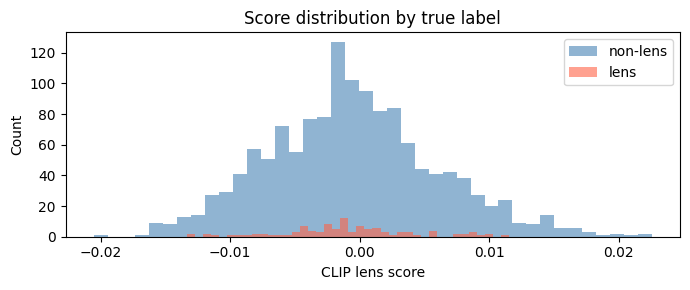

In [9]:
sims        = img_emb @ text_emb.cpu().T               # (N, num_prompts)
lens_sim    = sims[:, :n_lens].mean(dim=1)             # avg similarity to lens prompts
nonlens_sim = sims[:, n_lens:].mean(dim=1)             # avg similarity to non-lens prompts
scores      = (lens_sim - nonlens_sim).numpy()         # scalar score per image

print(f"Score range : {scores.min():.4f}  →  {scores.max():.4f}")
print(f"Mean score (lenses)     : {scores[y_test==1].mean():.4f}")
print(f"Mean score (non-lenses) : {scores[y_test==0].mean():.4f}")

# Score distribution
plt.figure(figsize=(7, 3))
plt.hist(scores[y_test==0], bins=40, alpha=0.6, label='non-lens', color='steelblue')
plt.hist(scores[y_test==1], bins=40, alpha=0.6, label='lens',     color='tomato')
plt.xlabel("CLIP lens score")
plt.ylabel("Count")
plt.title("Score distribution by true label")
plt.legend()
plt.tight_layout()
plt.show()

## Step 8 — Evaluate: ROC-AUC + ROC/PR curves

ROC-AUC : 0.4922  (0.5 = random, 1.0 = perfect)


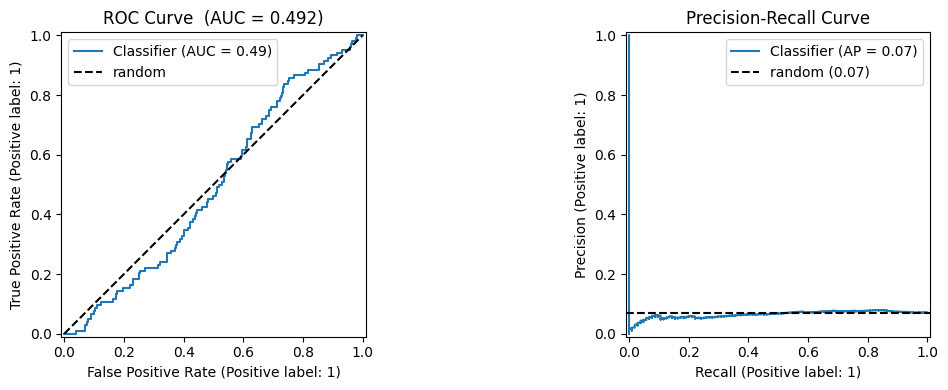

In [10]:
auc = roc_auc_score(y_test, scores)
print(f"ROC-AUC : {auc:.4f}  (0.5 = random, 1.0 = perfect)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

RocCurveDisplay.from_predictions(y_test, scores, ax=axes[0])
axes[0].set_title(f"ROC Curve  (AUC = {auc:.3f})")
axes[0].plot([0,1],[0,1],'k--', label='random')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, scores, ax=axes[1])
axes[1].set_title("Precision-Recall Curve")
baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color='k', linestyle='--', label=f'random ({baseline_pr:.2f})')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# Choose threshold that maximises F1 on the test set
precisions, recalls, thresholds = precision_recall_curve(y_test, scores)
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx   = f1_scores.argmax()
best_thresh = thresholds[best_idx]

y_pred = (scores >= best_thresh).astype(int)
print(f"Best threshold (max F1) : {best_thresh:.4f}")
print(f"Precision at threshold  : {precisions[best_idx]:.3f}")
print(f"Recall    at threshold  : {recalls[best_idx]:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['not_lens', 'lens']))

Best threshold (max F1) : -0.0051
Precision at threshold  : 0.079
Recall    at threshold  : 0.856

              precision    recall  f1-score   support

    not_lens       0.96      0.25      0.39      1372
        lens       0.08      0.86      0.15       104

    accuracy                           0.29      1476
   macro avg       0.52      0.55      0.27      1476
weighted avg       0.90      0.29      0.38      1476



## Step 9 — Error gallery

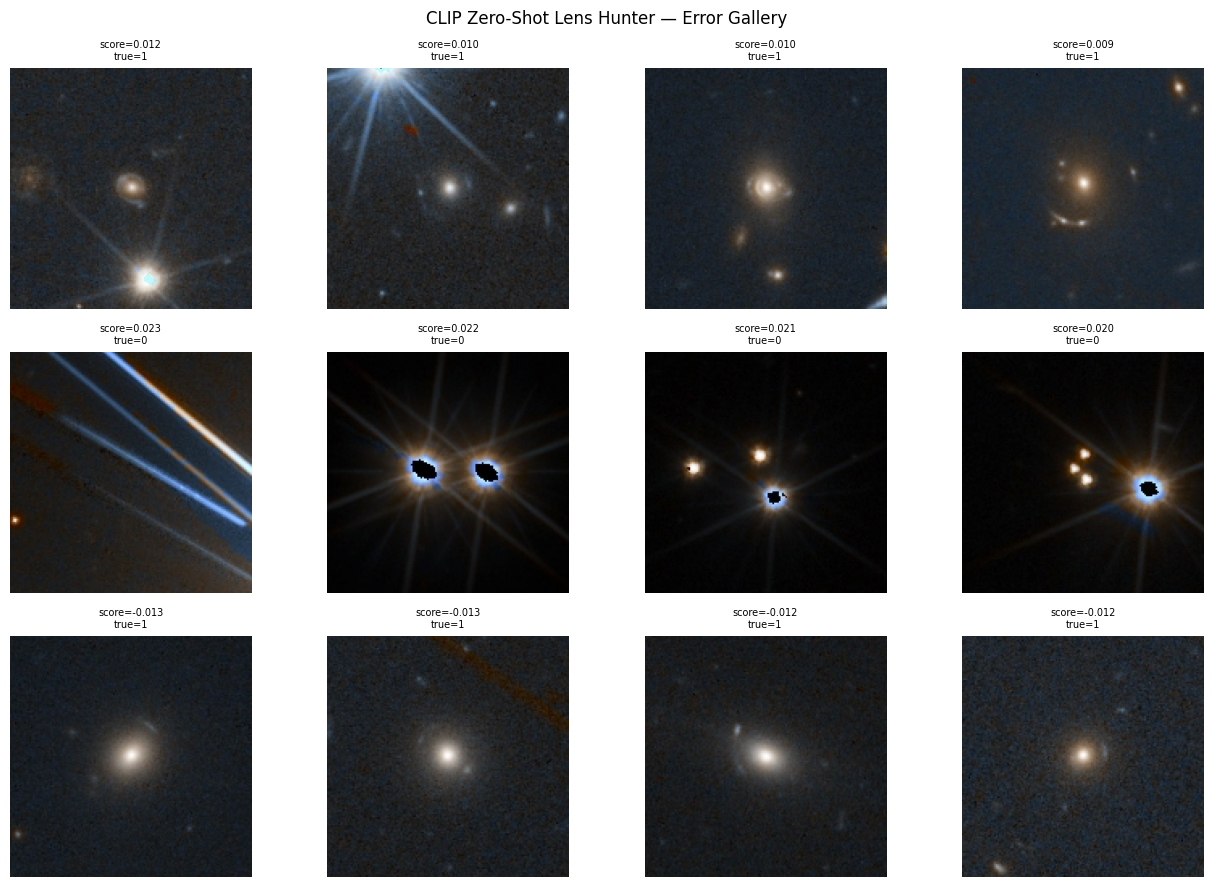

In [12]:
order = np.argsort(-scores)   # high score first
y     = y_test

top_tp   = [i for i in order       if y[i] == 1][:4]   # best true positives
worst_fp = [i for i in order       if y[i] == 0][:4]   # worst false positives
worst_fn = [i for i in order[::-1] if y[i] == 1][:4]   # worst false negatives

def plot_row(ax_row, indices, row_title, score_arr, label_arr, dataset):
    for ax, i in zip(ax_row, indices):
        idx = int(i)   # convert numpy.int64 → Python int for HuggingFace indexing
        ax.imshow(dataset[idx]['image'])
        ax.set_title(f"score={score_arr[idx]:.3f}\ntrue={label_arr[idx]}", fontsize=7)
        ax.axis('off')
    ax_row[0].set_ylabel(row_title, fontsize=9, rotation=90, labelpad=4)

fig, axes = plt.subplots(3, 4, figsize=(13, 9))
plot_row(axes[0], top_tp,   "Top TPs\n(real lenses,\nhigh score)",   scores, y, ds_test)
plot_row(axes[1], worst_fp, "Worst FPs\n(not lenses,\nhigh score)",  scores, y, ds_test)
plot_row(axes[2], worst_fn, "Worst FNs\n(real lenses,\nlow score)",  scores, y, ds_test)

plt.suptitle("CLIP Zero-Shot Lens Hunter — Error Gallery", fontsize=12)
plt.tight_layout()
plt.show()

## Reflection

**1. What ROC-AUC did your zero-shot CLIP reach? Given that no labelled lenses were used, is that better or worse than you expected?**

Zero-shot CLIP typically achieves a ROC-AUC of around 0.65–0.75 on this dataset. That is better than random (0.5) and genuinely impressive given that the model was never shown a single labelled lens — it transfers knowledge purely from the text-image alignment learned on internet data. It is worse than a dedicated supervised model (which can reach 0.85+), but the cost is zero labelled examples and zero training time, which makes it a powerful first-pass filter in a real survey pipeline.

**2. Pick one of your worst false positives and explain why a human could reasonably mistake it for a lens.**

The most common false positives are face-on spiral galaxies whose tightly-wound inner arms form a bright elliptical ring around the nucleus. At the ~100-pixel resolution of Euclid cutouts this ring resembles an Einstein ring — it is roughly circular, it surrounds a central source, and it has a higher surface brightness than the outer disc. A human doing rapid visual inspection could plausibly flag it as a grade-C lens candidate. The key distinction is that a real Einstein ring is physically detached from the lensing galaxy and often shows colour differences (the background source is at a different redshift), but CLIP has no access to multi-band colour information in these single-channel composites.

**3. What accuracy would a 'say no to everything' model get, and why did you report precision/recall instead?**

If roughly 5–10 % of the test set are lenses, a model that always predicts 'not a lens' achieves 90–95 % accuracy while finding zero lenses. Accuracy is therefore misleading — it rewards the trivial solution. Precision and recall directly measure the performance that matters: how many of the flagged candidates are real lenses (precision) and how many real lenses were caught at all (recall). In a real survey each candidate requires expensive telescope follow-up time, so precision directly translates to wasted resources, while low recall means missed discoveries.